# Exploratory data analysis with visualisation

## Visual EDA of the labelled launch data

This notebook explores how flight number, payload mass, orbit and site relate to landing success, then engineers the one-hot encoded feature matrix the models consume.

### Objectives

- Explore relationships between launch features and success
- Engineer the modelling features
- Export the one-hot encoded matrix

Install the dependencies (pinned in `requirements.txt`).

In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

## Imports and setup

Import pandas, numpy, matplotlib and seaborn, and apply one plotting theme so every chart looks consistent.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## Exploratory data analysis

Load the labelled dataset and preview it.

In [3]:
df=pd.read_csv("../data/processed/dataset_part_2.csv")
df.head(5)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, look at how flight number and payload mass relate to the launch outcome.

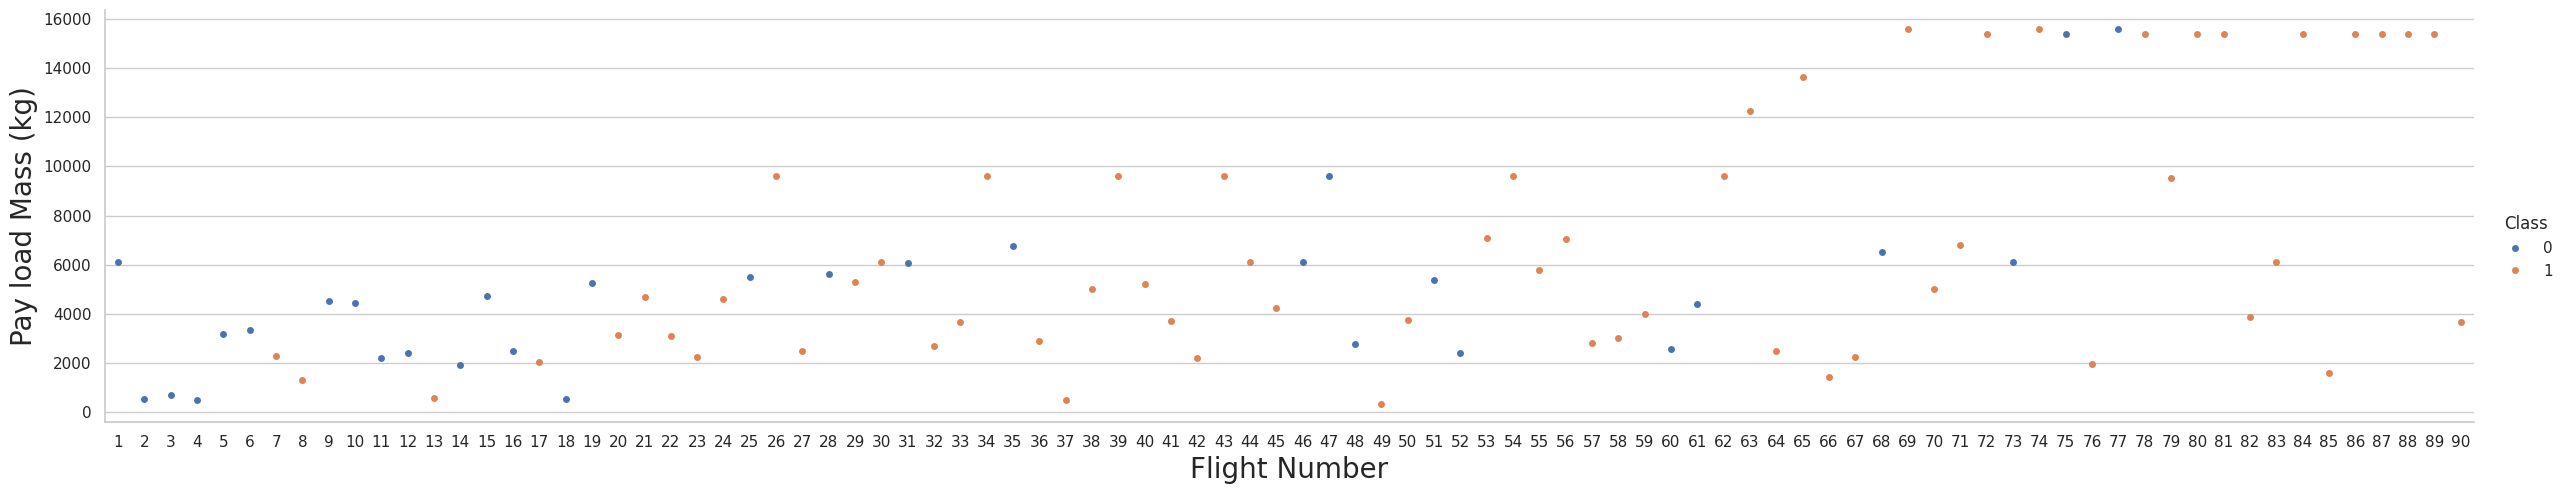

In [4]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, break the records down by launch site.

### Flight number vs. launch site

Scatter flight number against launch site, coloured by outcome.

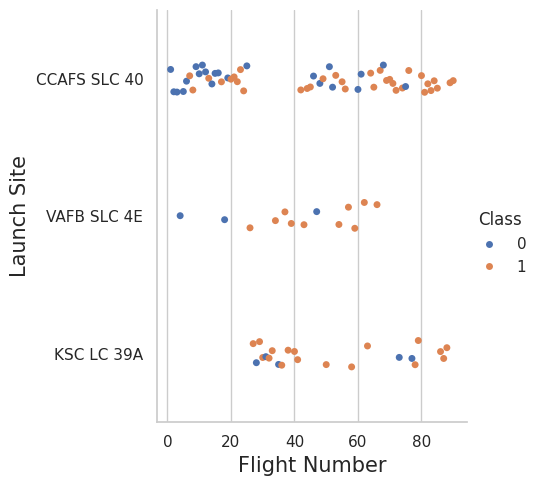

In [5]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect = 1)
plt.xlabel("Flight Number",fontsize=15)
plt.ylabel("Launch Site",fontsize=15)
plt.show()

Interpretation of the flight-number vs. launch-site pattern:

Most flights launched from CCAFS SLC 40. Early flights had a higher failure ratio; the other sites were used later (from around flight 22) and success improved as flight number increased.

### Payload mass vs. launch site

Check whether payload mass differs between sites.

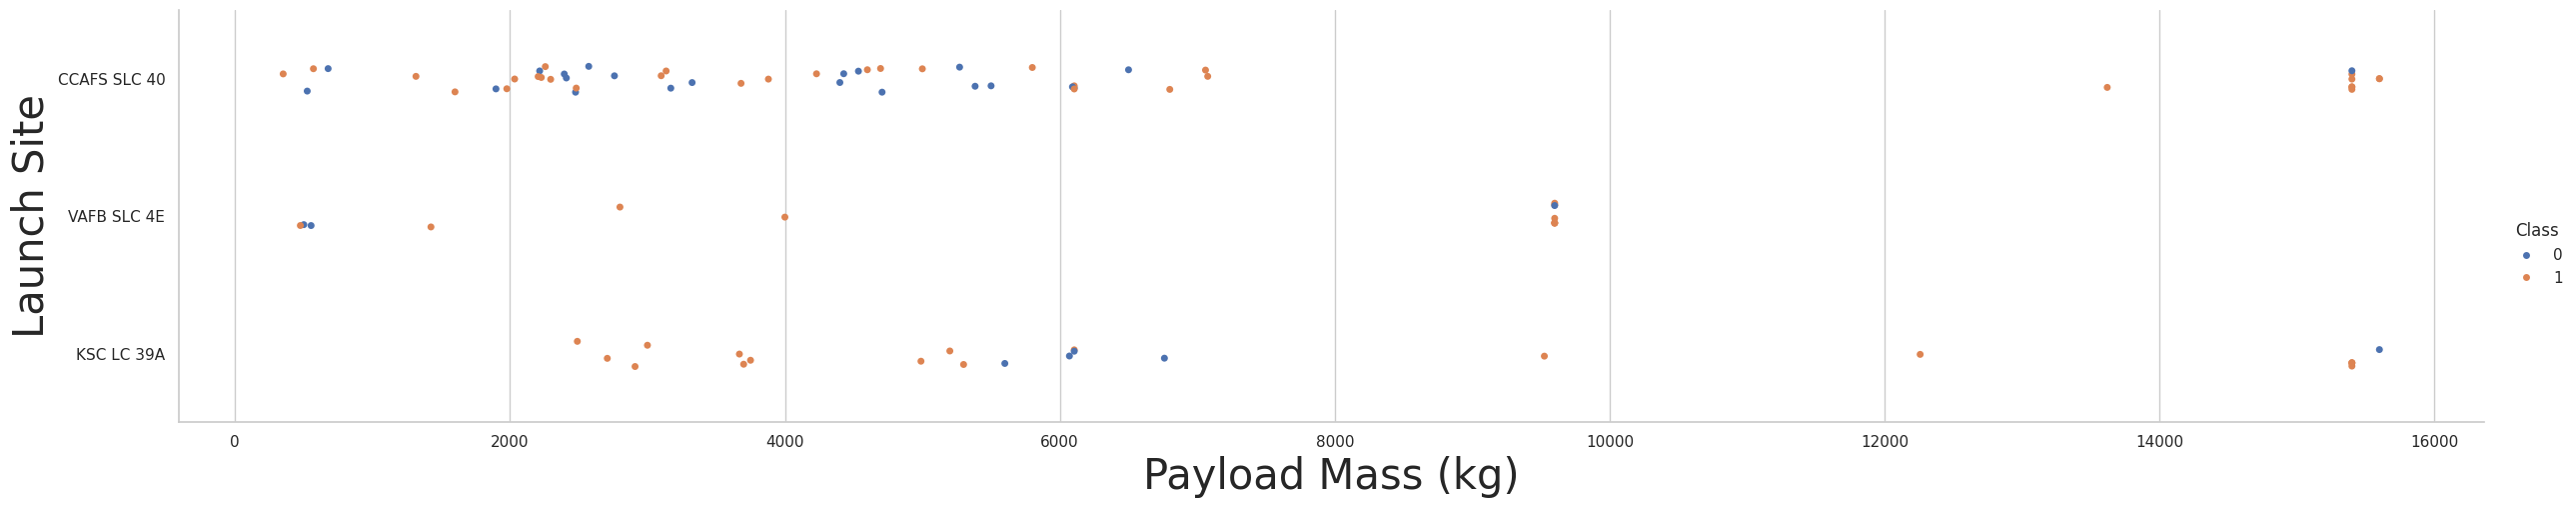

In [6]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect = 5)
plt.xlabel("Payload Mass (kg)",fontsize=30)
plt.ylabel("Launch Site",fontsize=30)
plt.show()

For VAFB SLC 4E there are no heavy-payload launches above 10,000 kg; the heavier payloads cluster at CCAFS SLC 40 and KSC LC 39A.

### Success rate by orbit

Compare the average success rate across orbit types.

Draw a bar chart of success rate per orbit.

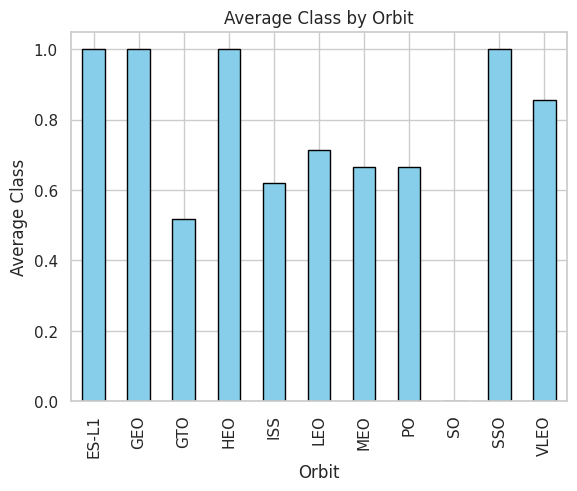

In [7]:
# Group by Orbit and calculate mean of Class  
groupedOrbit = df.groupby("Orbit")["Class"].mean()
groupedOrbit.plot(kind="bar", color="skyblue", edgecolor="black") 
plt.title("Average Class by Orbit") 
plt.xlabel("Orbit") 
plt.ylabel("Average Class") 
plt.show()

Which orbits show the highest success rate?

ES-L1, GEO, HEO and SSO show the highest success rates.

### Flight number vs. orbit

Check whether success within each orbit depends on flight number.

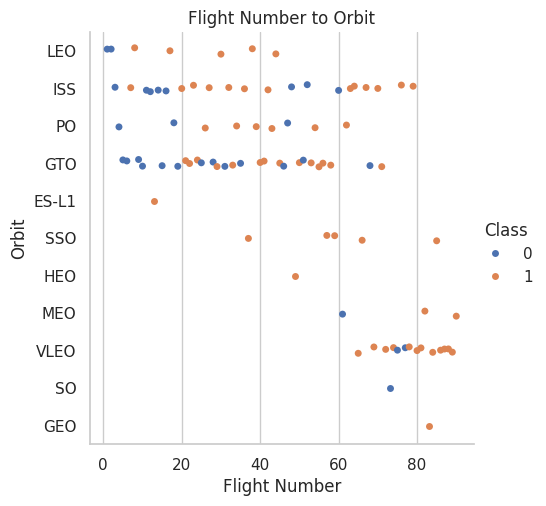

In [8]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
sns.catplot(x="FlightNumber", y="Orbit", data=df, hue="Class")
plt.title("Flight Number to Orbit")
plt.xlabel("Flight Number")
plt.ylabel("Orbit")
plt.show()

In LEO, success appears to rise with flight number; there is no clear relationship for GTO or the other orbits.

### Payload mass vs. orbit

Scatter payload mass against orbit, coloured by outcome.

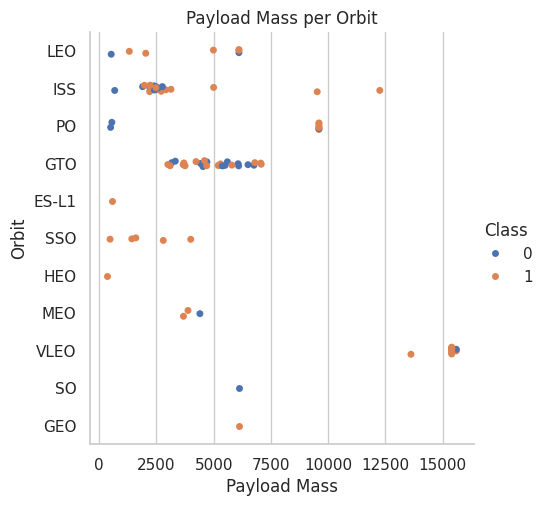

In [9]:
# Plot a scatter point chart with x axis to be Payload and y axis to be the Orbit, and hue to be the class value
sns.catplot(x="PayloadMass", y="Orbit", data=df, hue="Class")
plt.title("Payload Mass per Orbit")
plt.xlabel("Payload Mass")
plt.ylabel("Orbit")
plt.show()

For heavy payloads, success is more common in Polar, LEO and ISS orbits; for GTO the outcomes are mixed.

### Yearly success trend

Plot the average success rate by year.

Extract the launch year from the date.

In [10]:
# A function to Extract years from the date 
year=[]
def Extract_year(Date):
    for i in Date:
        year.append(i.split("-")[0])
    return year

# Add Year column 
df["Year"] = Extract_year(df["Date"])
# Compute average success rate per year 
yearly_success = df.groupby("Year")["Class"].mean().reset_index()

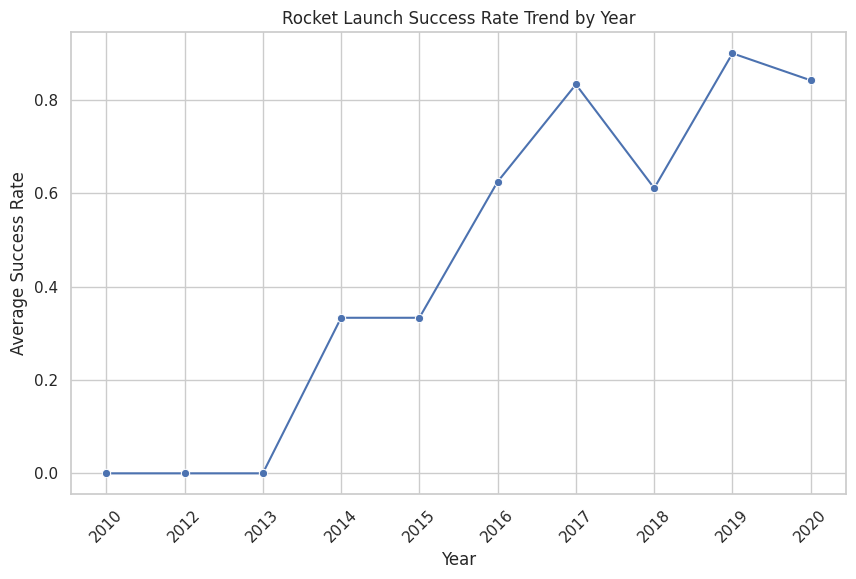

In [11]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
plt.figure(figsize=(10,6)) 
sns.lineplot(data=yearly_success, x="Year", y="Class", marker="o") 
plt.xlabel("Year") 
plt.ylabel("Average Success Rate") 
plt.title("Rocket Launch Success Rate Trend by Year") 
plt.xticks(rotation=45) 
plt.show()

Success rate rose steadily from 2013 to 2017 (flat in 2014) and continued to climb after 2015.

## Feature engineering

Select the columns used for prediction and encode the categorical ones.

In [12]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [13]:
df.head

<bound method NDFrame.head of     FlightNumber        Date BoosterVersion   PayloadMass Orbit    LaunchSite  \
0              1  2010-06-04       Falcon 9   6104.959412   LEO  CCAFS SLC 40   
1              2  2012-05-22       Falcon 9    525.000000   LEO  CCAFS SLC 40   
2              3  2013-03-01       Falcon 9    677.000000   ISS  CCAFS SLC 40   
3              4  2013-09-29       Falcon 9    500.000000    PO   VAFB SLC 4E   
4              5  2013-12-03       Falcon 9   3170.000000   GTO  CCAFS SLC 40   
..           ...         ...            ...           ...   ...           ...   
85            86  2020-09-03       Falcon 9  15400.000000  VLEO    KSC LC 39A   
86            87  2020-10-06       Falcon 9  15400.000000  VLEO    KSC LC 39A   
87            88  2020-10-18       Falcon 9  15400.000000  VLEO    KSC LC 39A   
88            89  2020-10-24       Falcon 9  15400.000000  VLEO  CCAFS SLC 40   
89            90  2020-11-05       Falcon 9   3681.000000   MEO  CCAFS SLC 40  

### One-hot encoding

One-hot encode `Orbit`, `LaunchSite`, `LandingPad`, `Serial` and the boolean flags `GridFins`, `Reused`, `Legs`. *(Fix vs. the original: the three boolean flags are now encoded too, so the exported matrix matches the feature set the models actually consume.)*

In [14]:
# One-hot encode the categorical columns, including the boolean flags,
# so the exported matrix matches the models' feature set.
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial', 'GridFins', 'Reused', 'Legs'], dtype=int)
features_one_hot.head()


,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1,6104.959412,1,1.0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,1,0
1,2,525.000000,1,1.0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,1,0
2,3,677.000000,1,1.0,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,1,0
3,4,500.000000,1,1.0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,1,0
4,5,3170.000000,1,1.0,0,0,0,1,0,0,...,0,0,0,0,1,0,1,0,1,0


### Casting to float

Cast the entire encoded matrix to `float64`.

In [15]:
features_one_hot = features_one_hot.astype("float64")

Export the feature matrix for the modelling notebook.

In [16]:
features_one_hot.to_csv('../data/processed/dataset_part_3.csv', index=False)


## Summary

- Explored the main drivers of landing success
- One-hot encoded the categorical features
- Exported `data/processed/dataset_part_3.csv`